# Visualizations from Processed Annual Permit Metrics

This notebook loads two small processed CSV files exported by `notebooks/03_building_permits_preparation_and_analysis.ipynb` and produces the first portfolio-ready visualizations for this project.

**Why use processed files instead of the raw data?**
The raw Issued Building Permits file is approximately 56 MB. Reloading and re-filtering it here would add unnecessary overhead. The two processed outputs are six-row summary tables — a few hundred bytes each — that load instantly. This pattern also ensures these charts always reflect the validated, documented pipeline rather than ad-hoc filtering applied directly in a visualization notebook.

**Planned outputs:**
- `visuals/permit_count_by_year.png` — bar chart of annual residential permit count
- `visuals/permit_project_value_by_year.png` — bar chart of annual total residential project value

These are early portfolio visuals and will later support the dashboard and business narrative.

## 1. Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path


## 2. Paths and output directory

`PROJECT_ROOT` is resolved relative to this notebook's location so the paths work regardless of where Jupyter is launched from. The `visuals/` directory is created if it does not already exist.

In [2]:
try:
    PROJECT_ROOT = Path(__file__).resolve().parent.parent
except NameError:
    _cwd = Path.cwd()
    PROJECT_ROOT = _cwd.parent if _cwd.name == "notebooks" else _cwd

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
VISUALS_DIR   = PROJECT_ROOT / "visuals"

PERMIT_COUNT_PATH = PROCESSED_DIR / "permit_count_by_year.csv"
PERMIT_VALUE_PATH = PROCESSED_DIR / "permit_project_value_by_year.csv"

PERMIT_COUNT_PNG = VISUALS_DIR / "permit_count_by_year.png"
PERMIT_VALUE_PNG = VISUALS_DIR / "permit_project_value_by_year.png"

VISUALS_DIR.mkdir(parents=True, exist_ok=True)

print(f"Project root : {PROJECT_ROOT}")
print(f"Processed dir: {PROCESSED_DIR}")
print(f"Visuals dir  : {VISUALS_DIR}")


Project root : c:\Users\User\Documents\vancouver-property-value-housing-supply-analysis
Processed dir: c:\Users\User\Documents\vancouver-property-value-housing-supply-analysis\data\processed
Visuals dir  : c:\Users\User\Documents\vancouver-property-value-housing-supply-analysis\visuals


## 3. Load processed CSV files

Both files are small (six rows each). No sampling or chunking is required.

In [3]:
permit_count_by_year         = pd.read_csv(PERMIT_COUNT_PATH)
permit_project_value_by_year = pd.read_csv(PERMIT_VALUE_PATH)

print("permit_count_by_year")
print(permit_count_by_year.to_string(index=False))
print()
print("permit_project_value_by_year")
print(permit_project_value_by_year.to_string(index=False))


permit_count_by_year
 IssueYear  permit_count
      2019          3731
      2020          3165
      2021          3702
      2022          4501
      2023          3408
      2024          3437

permit_project_value_by_year
 IssueYear  total_project_value  median_project_value  mean_project_value  permit_count
      2019         1.673854e+09               35000.0        4.486341e+05          3731
      2020         1.608853e+09               30900.0        5.083265e+05          3165
      2021         1.609825e+09               20000.0        4.348527e+05          3702
      2022         3.720902e+09               25000.0        8.266834e+05          4501
      2023         3.945624e+09               30000.0        1.157754e+06          3408
      2024         2.870462e+09               45000.0        8.351649e+05          3437


## 4. Validate inputs

Before plotting, verify that each file meets the expected contract: correct columns, exactly six rows, `IssueYear` values 2019–2024 in ascending order. Any failure here indicates the source notebook produced unexpected output and should be investigated before regenerating charts.

In [4]:
EXPECTED_COUNT_COLS = ["IssueYear", "permit_count"]
EXPECTED_VALUE_COLS = [
    "IssueYear", "total_project_value", "median_project_value",
    "mean_project_value", "permit_count",
]
EXPECTED_YEARS     = list(range(2019, 2025))
EXPECTED_ROW_COUNT = 6


def validate_permit_df(df, path, expected_cols, label):
    issues = []
    if not path.exists():
        issues.append(f"File not found: {path}")
        return issues
    missing = [c for c in expected_cols if c not in df.columns]
    if missing:
        issues.append(f"Missing columns: {missing}")
    if len(df) != EXPECTED_ROW_COUNT:
        issues.append(f"Expected {EXPECTED_ROW_COUNT} rows, found {len(df)}")
    if "IssueYear" in df.columns:
        actual_years = df["IssueYear"].tolist()
        if sorted(actual_years) != EXPECTED_YEARS:
            issues.append(f"IssueYear values out of range: {actual_years}")
        if actual_years != sorted(actual_years):
            issues.append("IssueYear is not sorted ascending")
    if issues:
        print(f"[FAIL] {label}")
        for msg in issues:
            print(f"  - {msg}")
    else:
        print(f"[PASS] {label}  ({len(df)} rows, columns: {list(df.columns)})")
    return issues


count_issues = validate_permit_df(
    permit_count_by_year, PERMIT_COUNT_PATH, EXPECTED_COUNT_COLS,
    "permit_count_by_year",
)
value_issues = validate_permit_df(
    permit_project_value_by_year, PERMIT_VALUE_PATH, EXPECTED_VALUE_COLS,
    "permit_project_value_by_year",
)

assert not count_issues, "permit_count_by_year failed validation — fix before plotting"
assert not value_issues, "permit_project_value_by_year failed validation — fix before plotting"


[PASS] permit_count_by_year  (6 rows, columns: ['IssueYear', 'permit_count'])
[PASS] permit_project_value_by_year  (6 rows, columns: ['IssueYear', 'total_project_value', 'median_project_value', 'mean_project_value', 'permit_count'])


## 5. Chart 1 — Annual Residential Permit Count

A bar chart showing the number of distinct residential building permits issued each year from 2019 to 2024. Each bar represents unique permit applications counted by `PermitNumber`, filtered to records where `PropertyUse` contains `"Dwelling Uses"`.

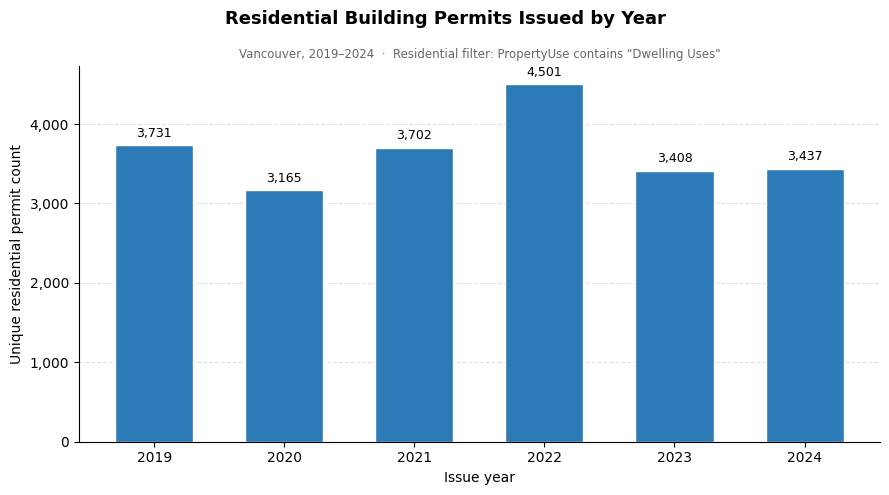

Saved: c:\Users\User\Documents\vancouver-property-value-housing-supply-analysis\visuals\permit_count_by_year.png


In [5]:
FIG_WIDTH  = 9
FIG_HEIGHT = 5
BAR_COLOR  = "#2C7BB6"
DPI        = 300

x_labels = permit_count_by_year["IssueYear"].astype(str)
y_values  = permit_count_by_year["permit_count"]

fig, ax = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
bars = ax.bar(x_labels, y_values, color=BAR_COLOR, edgecolor="white", width=0.6)

fig.suptitle("Residential Building Permits Issued by Year", fontsize=13, fontweight="bold")
ax.set_title(
    'Vancouver, 2019–2024  ·  Residential filter: PropertyUse contains "Dwelling Uses"',
    fontsize=8.5, color="#666666", pad=6,
)
ax.set_xlabel("Issue year", fontsize=10)
ax.set_ylabel("Unique residential permit count", fontsize=10)

ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.35, color="#aaaaaa")
ax.set_axisbelow(True)

for bar in bars:
    height = bar.get_height()
    ax.annotate(
        f"{int(height):,}",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4), textcoords="offset points",
        ha="center", va="bottom", fontsize=9,
    )

plt.tight_layout()
plt.savefig(PERMIT_COUNT_PNG, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {PERMIT_COUNT_PNG}")


### Interpretation note

This chart shows the volume of residential building permit activity in Vancouver each year. It reflects *approved permit applications*, not housing units completed or added to the housing stock. A single permit may cover a single-family renovation, a small infill duplex, or a large apartment building with hundreds of units — the count treats each permit equally regardless of scale. This metric is best read as a signal of the pace and breadth of approved residential construction activity.

## 6. Chart 2 — Annual Residential Project Value

A bar chart showing the total declared `ProjectValue` of residential building permits issued each year, expressed in billions of Canadian dollars. `ProjectValue` is the applicant-declared estimated construction cost and is used here as a proxy for the investment intensity of residential construction activity.

The visual constants `FIG_WIDTH`, `FIG_HEIGHT`, `BAR_COLOR`, and `DPI` are defined in Section 5 and reused here.

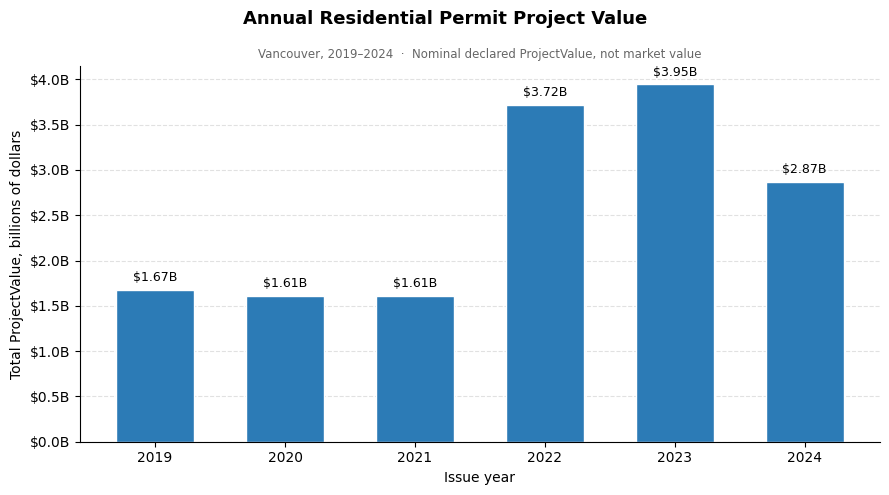

Saved: c:\Users\User\Documents\vancouver-property-value-housing-supply-analysis\visuals\permit_project_value_by_year.png


In [6]:
BILLIONS = 1_000_000_000

x_labels_pv = permit_project_value_by_year["IssueYear"].astype(str)
y_values_pv  = permit_project_value_by_year["total_project_value"] / BILLIONS

fig2, ax2 = plt.subplots(figsize=(FIG_WIDTH, FIG_HEIGHT))
bars2 = ax2.bar(x_labels_pv, y_values_pv, color=BAR_COLOR, edgecolor="white", width=0.6)

fig2.suptitle("Annual Residential Permit Project Value", fontsize=13, fontweight="bold")
ax2.set_title(
    "Vancouver, 2019–2024  ·  Nominal declared ProjectValue, not market value",
    fontsize=8.5, color="#666666", pad=6,
)
ax2.set_xlabel("Issue year", fontsize=10)
ax2.set_ylabel("Total ProjectValue, billions of dollars", fontsize=10)

ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:.1f}B"))
ax2.spines["top"].set_visible(False)
ax2.spines["right"].set_visible(False)
ax2.grid(axis="y", linestyle="--", alpha=0.35, color="#aaaaaa")
ax2.set_axisbelow(True)

for bar in bars2:
    height = bar.get_height()
    ax2.annotate(
        f"${height:.2f}B",
        xy=(bar.get_x() + bar.get_width() / 2, height),
        xytext=(0, 4), textcoords="offset points",
        ha="center", va="bottom", fontsize=9,
    )

plt.tight_layout()
plt.savefig(PERMIT_VALUE_PNG, dpi=DPI, bbox_inches="tight")
plt.show()
print(f"Saved: {PERMIT_VALUE_PNG}")


### Interpretation note

`ProjectValue` is the construction and project value declared by the permit applicant at the time of application. It is not independently verified and does not represent BC Assessment assessed value, MLS sale price, or property market value.

All figures are in **nominal Canadian dollars** and have not been adjusted for inflation. Year-over-year changes in total project value therefore reflect a combination of changes in construction volume *and* changes in construction costs over time.

Large individual projects — such as high-rise residential developments — can materially skew annual totals. The `median_project_value` column in the processed file provides a more outlier-resistant alternative and will be incorporated in later analysis.

## 7. Output validation

Verify that both PNG files were saved to `visuals/`. Check existence and file size before concluding.

In [7]:
outputs = [("permit_count_by_year.png",         PERMIT_COUNT_PNG),
    ("permit_project_value_by_year.png", PERMIT_VALUE_PNG),]

print("Output file validation")
print("-" * 50)
for label, path in outputs:
    if path.exists():
        size_kb = path.stat().st_size / 1024
        print(f"[EXISTS]  {label}")
        print(f"          Path    : {path}")
        print(f"          Size    : {size_kb:.1f} KB")
    else:
        print(f"[MISSING] {label}")
        print(f"          Expected: {path}")


Output file validation
--------------------------------------------------
[EXISTS]  permit_count_by_year.png
          Path    : c:\Users\User\Documents\vancouver-property-value-housing-supply-analysis\visuals\permit_count_by_year.png
          Size    : 108.6 KB
[EXISTS]  permit_project_value_by_year.png
          Path    : c:\Users\User\Documents\vancouver-property-value-housing-supply-analysis\visuals\permit_project_value_by_year.png
          Size    : 127.7 KB
